Imports PyTorch + torchvision (for CIFAR-10)

Imports DataLoader (to batch data)

Sets device to GPU if available

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch version:", torch.__version__)

Device: cuda
Torch version: 2.10.0+cu128


CIFAR-10 dataset

Downloads CIFAR-10 automatically into ./data

Creates:

train_set (50,000 images)

test_set (10,000 images)

Converts each image to a tensor using ToTensor()

Important: ToTensor() converts images from:

pixel range 0–255 → float range 0–1

shape becomes (C, H, W) = (3, 32, 32)

In [2]:
# NO normalization, NO augmentation.
# Loading raw images first.
basic_transform = transforms.ToTensor()

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=basic_transform
)

test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=basic_transform
)

print("Train size:", len(train_set))
print("Test size:", len(test_set))
print("Class names:", train_set.classes)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


Train size: 50000
Test size: 10000
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


ONE data sample
x is the image tensor

y is the label (0–9)

x.shape = (3, 32, 32) means:

3 channels (RGB)

32x32 pixels

In [3]:
x, y = train_set[0]  # first training example

print("x type:", type(x))
print("x shape:", x.shape)          # should be torch.Size([3, 32, 32])
print("x dtype:", x.dtype)          # float32
print("x min/max:", x.min().item(), x.max().item())

print("y:", y)
print("y class name:", train_set.classes[y])

x type: <class 'torch.Tensor'>
x shape: torch.Size([3, 32, 32])
x dtype: torch.float32
x min/max: 0.0 1.0
y: 6
y class name: frog


Display the image - visualize what CIFAR-10 looks like

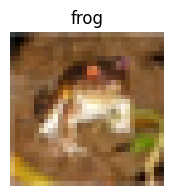

In [4]:
def show_image(img_tensor, label):
    # img_tensor: (3, 32, 32)
    img = img_tensor.permute(1, 2, 0)  # (H, W, C) for matplotlib
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    plt.title(train_set.classes[label])
    plt.axis("off")
    plt.show()

show_image(x, y)

Show a grid of multiple images---
CIFAR-10 is small images (32×32)---
Some classes look similar (cat vs dog), which is why it’s challenging

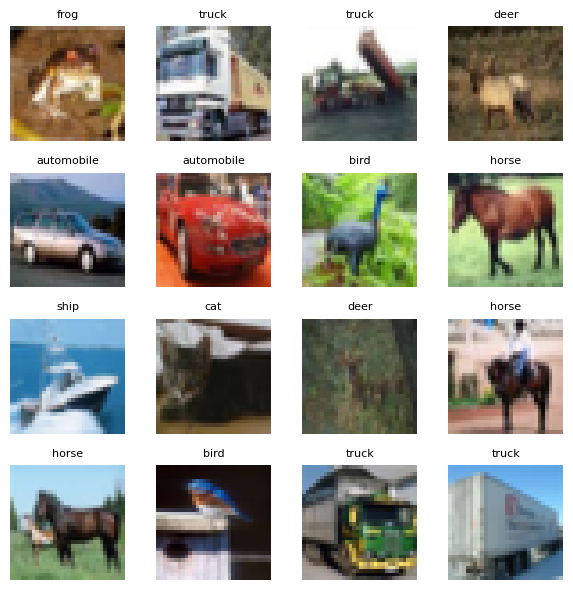

In [5]:
def show_batch(dataset, n=16):
    plt.figure(figsize=(6,6))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)
        plt.subplot(4, 4, i+1)
        plt.imshow(img)
        plt.title(train_set.classes[label], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_set, n=16)

DataLoader

Instead of feeding 1 image at a time, training uses batches

xb.shape = (128, 3, 32, 32) means 128 images at once

In [6]:
batch_size = 128

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch image shape:", xb.shape)  # (batch_size, 3, 32, 32)
print("Batch label shape:", yb.shape)  # (batch_size,)
print("First 10 labels:", yb[:10].tolist())

Batch image shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])
First 10 labels: [6, 2, 0, 1, 6, 6, 1, 0, 0, 3]


check class balance

In [7]:
from collections import Counter

labels = [train_set[i][1] for i in range(len(train_set))]
counts = Counter(labels)

for k in range(10):
    print(train_set.classes[k], ":", counts[k])

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


Flatten the image (turn 3×32×32 into 3072 numbers)

A fully connected network expects a 2D input: (batch, features)

CIFAR image (3,32,32) → 3*32*32 = 3072 features

Now you have (B, 3072)

In [8]:

xb, yb = next(iter(train_loader))  # xb: (B, 3, 32, 32)

print("Before flatten:", xb.shape)

xb_flat = xb.view(xb.shape[0], -1)  # (B, 3072)

print("After flatten:", xb_flat.shape)
print("One image becomes length:", xb_flat.shape[1])

Before flatten: torch.Size([128, 3, 32, 32])
After flatten: torch.Size([128, 3072])
One image becomes length: 3072


Manual Fully Connected (Linear) layer

Creates parameters W and b

Forward: x @ W + b

Backward computes:

dW, db (how to change weights/bias)

dx (gradient to pass to previous layer)

In [9]:
# Built in connected layer
# import torch
# import torch.nn as nn

# # Create built-in fully connected layer
# fc = nn.Linear(in_features=3072, out_features=256)

# # Example input (batch of 128 images flattened)
# x = torch.randn(128, 3072)

# # Forward pass
# out = fc(x)

# print("Output shape:", out.shape)

class Linear:
    def __init__(self, in_features, out_features, weight_scale=0.01, device="cpu"):
        # """
        # Fully Connected (Linear) Layer

        # This layer performs:
        #     y = xW + b

        # Where:
        #     x: input of shape (N, D)
        #     W: weights of shape (D, M)
        #     b: bias of shape (M,)
        #     y: output of shape (N, M)

        # N = batch size
        # D = number of input features
        # M = number of output features
        # """
        # Initialize weights W with small random values
        self.W = weight_scale * torch.randn(in_features, out_features, device=device)

        # Initialize bias b as zeros
        self.b = torch.zeros(out_features, device=device)

        # gradients (filled during backward)
        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        # cache input for backward
        self.x = None

    def forward(self, x):
        # """
        # Forward Pass

        # Formula:
        #     y = xW + b

        # Shapes:
        #     x: (N, D)
        #     W: (D, M)
        #     b: (M,)
        #     y: (N, M)
        # """
        self.x = x
        return x @ self.W + self.b  # (N, M)

    def backward(self, dout):
        # """
        # Backward Pass (Gradient Computation)

        # Given:
        #     dout = dL/dy  (gradient of loss w.r.t output)

        # We compute:

        # 1. Gradient w.r.t weights:
        #     dW = x^T · dout

        # 2. Gradient w.r.t bias:
        #     db = sum(dout over batch)

        # 3. Gradient w.r.t input:
        #     dx = dout · W^T

        # Shapes:
        #     dout: (N, M)
        #     x:    (N, D)

        #     dW:   (D, M)
        #     db:   (M,)
        #     dx:   (N, D)
        # """

        # dW = x^T * dout
        self.dW = self.x.t() @ dout

        # db = sum over batch dimension
        self.db = dout.sum(dim=0)

        # dx = dout * W^T
        dx = dout @ self.W.t()

        return dx

Manual ReLU

Forward: removes negatives

Backward: only passes gradient where input was positive


In [10]:
class ReLU:
    def __init__(self):
        # """
        # ReLU Activation Layer

        # Applies the function:
        #     ReLU(x) = max(0, x)

        # Stores a mask to use during backpropagation.
        # """
        self.mask = None

    def forward(self, x):
        """
        Forward Pass

        Formula:
            y = max(0, x)

        Implementation:
            - Create a mask where x > 0
            - Multiply input by mask

        Shapes:
            x: (N, D) or any shape
            output: same shape as x
        """

        #Create mask: True where x > 0, False otherwise
        self.mask = (x > 0)
        # Apply ReLU: keep positives, zero out negatives
        out = x * self.mask

        return out

    def backward(self, dout):
        """
        Backward Pass

        Given:
            dout = dL/dy

        ReLU derivative:
            d(ReLU)/dx =
                1 if x > 0
                0 if x <= 0

        So:
            dx = dout * mask

        Shapes:
            dout: same shape as input
            dx: same shape as input
        """

        # Pass gradient only where input was positive
        dx = dout * self.mask

        return dx

Softmax + Cross-Entropy loss

Converts logits → probabilities (softmax)

Computes loss (how wrong the model is)

Returns gradient dlogits which starts backprop

In [11]:
import torch

def softmax(logits):
    """
    Softmax Function

    Converts raw model outputs (logits) into probabilities.

    Formula:
        softmax(z_i) = exp(z_i) / sum(exp(z_j))

    For numerical stability, we subtract the maximum logit in each row:
        z_stable = z - max(z)

    This does not change the final probabilities, but prevents overflow.

    Input:
        logits: tensor of shape (N, C)
            N = batch size
            C = number of classes

    Output:
        probs: tensor of shape (N, C)
            Each row sums to 1
    """

    # Subtract max value from each row for numerical stability
    z = logits - logits.max(dim=1, keepdim=True).values

    # Apply exponential
    exp = torch.exp(z)

    # Normalize so each row sums to 1
    probs = exp / exp.sum(dim=1, keepdim=True)

    return probs


def cross_entropy_loss_from_logits(logits, y):
    """
    Cross-Entropy Loss from Logits

    This function computes:
    1. Softmax probabilities
    2. Cross-entropy loss
    3. Gradient of loss with respect to logits

    Inputs:
        logits: tensor of shape (N, C)
            Raw outputs from the model

        y: tensor of shape (N,)
            True class labels (integer class indices)

    Returns:
        loss: scalar
        dlogits: tensor of shape (N, C)

    --------------------------------------------------
    Step 1: Convert logits to probabilities using softmax

        p_i = exp(z_i) / sum_j exp(z_j)

    --------------------------------------------------
    Step 2: Compute cross-entropy loss

        L = -1/N * sum(log(p(correct class)))

    More explicitly:
        L = -1/N * sum_{i=1 to N} log(p[i, y_i])

    --------------------------------------------------
    Step 3: Compute gradient with respect to logits

        dL/dlogits = (probs - one_hot(y)) / N
    """

    # Get batch size N and number of classes C
    N, C = logits.shape

    # Convert logits to probabilities
    probs = softmax(logits)

    # Small value added to avoid log(0)
    eps = 1e-12

    # Get probability assigned to the correct class for each sample
    correct_probs = probs[torch.arange(N), y]

    # Compute average cross-entropy loss
    loss = (-torch.log(correct_probs + eps)).mean()

    # Compute gradient of loss with respect to logits
    dlogits = probs.clone()

    # Subtract 1 from the probability of the correct class
    dlogits[torch.arange(N), y] -= 1.0

    # Average over batch size
    dlogits /= N

    return loss, dlogits

FC Neural Network model

Combines layers into a model

Forward produces logits

Backward propagates gradients through layers

params() returns all weights and gradients so we can update them


In [12]:
class FCNet:
    def __init__(self, input_dim=3072, hidden_dim=256, num_classes=10, device="cpu"):
        """
        Fully Connected Neural Network

        Architecture:
            Input -> Linear -> ReLU -> Linear -> Output logits

        For CIFAR-10:
            Input image shape = (N, 3, 32, 32)

        After flattening:
            3 * 32 * 32 = 3072 features

        So the network computes:

            x_flat = reshape(x)

            h1 = x_flat W1 + b1
            a1 = ReLU(h1)
            logits = a1 W2 + b2

        Where:
            x_flat: (N, 3072)
            W1:     (3072, hidden_dim)
            b1:     (hidden_dim,)
            W2:     (hidden_dim, num_classes)
            b2:     (num_classes,)

        N = batch size
        """

        # First fully connected layer:
        # maps input features -> hidden layer
        self.fc1 = Linear(input_dim, hidden_dim, device=device)

        # ReLU activation layer
        self.relu = ReLU()

        # Second fully connected layer:
        # maps hidden layer -> output classes
        self.fc2 = Linear(hidden_dim, num_classes, device=device)

    def forward(self, x):
        """
        Forward Pass

        Input:
            x: tensor of shape (N, 3, 32, 32)

        Step 1: Flatten image into a vector
            x_flat shape = (N, 3072)

        Step 2: First linear layer
            h1 = x_flat W1 + b1

        Step 3: ReLU activation
            a1 = ReLU(h1)

        Step 4: Second linear layer
            logits = a1 W2 + b2

        Output:
            logits: tensor of shape (N, 10)
        """

        # Flatten each image from (3, 32, 32) into a vector of length 3072
        x = x.view(x.shape[0], -1)

        # First linear transformation
        x = self.fc1.forward(x)

        # Apply ReLU activation
        x = self.relu.forward(x)

        # Final linear transformation to get class scores (logits)
        logits = self.fc2.forward(x)

        return logits

    def backward(self, dlogits):
        """
        Backward Pass

        Input:
            dlogits = gradient of loss with respect to output logits
                    shape: (N, num_classes)

        Backpropagation order:
            1. Backward through second linear layer
            2. Backward through ReLU
            3. Backward through first linear layer

        This applies the chain rule:
            dL/dx = dL/dlogits * dlogits/da1 * da1/dh1 * dh1/dx
        """

        # Backprop through second linear layer
        dx = self.fc2.backward(dlogits)

        # Backprop through ReLU
        dx = self.relu.backward(dx)

        # Backprop through first linear layer
        dx = self.fc1.backward(dx)

        return dx

    def params(self):
        """
        Return all learnable parameters and their gradients.

        This is useful for manual parameter updates, for example:

            for param, grad in model.params():
                param -= learning_rate * grad

        Returns:
            List of tuples:
                (parameter, gradient)
        """

        return [
            (self.fc1.W, self.fc1.dW),
            (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),
            (self.fc2.b, self.fc2.db),
        ]

Manual gradient descent update

In [13]:
def sgd_step(params, lr=0.1):
    for p, dp in params:
        p -= lr * dp

Accuracy function

In [14]:
@torch.no_grad()
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

Training loop

Trains for multiple epochs

Each iteration:

forward

loss

backward

update

Stores:

loss_history (per batch/iteration)

train/test accuracy (per epoch)

In [15]:
def train_fc(model, train_loader, test_loader, epochs=5, lr=0.1, device="cpu"):
    """
    Train a fully connected neural network using manual forward pass,
    manual backward pass, and manual SGD updates.

    Inputs:
        model       : custom FCNet model
        train_loader: training data loader
        test_loader : test data loader
        epochs      : number of training epochs
        lr          : learning rate
        device      : "cpu" or "cuda"

    Returns:
        loss_history   : training loss recorded at each iteration
        train_acc_hist : average training accuracy for each epoch
        test_acc_hist  : average test accuracy for each epoch
    """

    # Store metrics during training
    loss_history = []      # loss for each training batch
    train_acc_hist = []    # average training accuracy per epoch
    test_acc_hist = []     # average test accuracy per epoch

    # Repeat training for the specified number of epochs
    for epoch in range(1, epochs + 1):
        model_loss = 0.0
        model_acc = 0.0
        steps = 0

        # Loop through each batch in the training set
        for xb, yb in train_loader:
            # Move input batch and labels to the selected device
            xb = xb.to(device)
            yb = yb.to(device)

            # --------------------------------------------------
            # Step 1: Forward pass
            # logits = model output before softmax
            # Shape: (N, num_classes)
            # --------------------------------------------------
            logits = model.forward(xb)

            # --------------------------------------------------
            # Step 2: Compute loss and gradient w.r.t. logits
            #
            # Cross-entropy loss:
            #     L = -1/N * sum log(p(correct class))
            #
            # dlogits is the gradient of loss w.r.t logits
            # --------------------------------------------------
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # --------------------------------------------------
            # Step 3: Backward pass
            # Propagate gradients through the custom network
            # --------------------------------------------------
            model.backward(dlogits)

            # --------------------------------------------------
            # Step 4: Update parameters manually using SGD
            #
            # Formula:
            #     parameter = parameter - lr * gradient
            # --------------------------------------------------
            sgd_step(model.params(), lr=lr)

            # Record batch loss
            loss_history.append(loss.item())

            # Accumulate total loss and accuracy for this epoch
            model_loss += loss.item()
            model_acc += accuracy_from_logits(logits, yb)
            steps += 1

        # Compute average training accuracy for this epoch
        train_acc = model_acc / steps
        train_acc_hist.append(train_acc)

        # Evaluate model on test data
        test_acc = evaluate(model, test_loader, device=device)
        test_acc_hist.append(test_acc)

        # Print epoch summary
        print(f"Epoch {epoch}: train_loss={model_loss/steps:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

    return loss_history, train_acc_hist, test_acc_hist


@torch.no_grad()
def evaluate(model, loader, device="cpu"):
    """
    Evaluate model accuracy on validation or test data.

    No gradient tracking is needed during evaluation.

    Accuracy formula:
        accuracy = (# correct predictions) / (total predictions)
    """

    acc_sum = 0.0
    steps = 0

    # Loop through evaluation batches
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        # Forward pass only
        logits = model.forward(xb)

        # Add batch accuracy
        acc_sum += accuracy_from_logits(logits, yb)
        steps += 1

    # Return average accuracy across all batches
    return acc_sum / steps

In [16]:

# Create an instance of the custom Fully Connected Network (FCNet)
#
# This initializes all layers:
#   - fc1 (Linear layer)
#   - ReLU activation
#   - fc2 (Linear layer)
#
# The model will learn parameters (W, b) during training
model = FCNet(device=device)



# Train the model using the custom training function
#
# Inputs:
#   model         : our custom neural network
#   train_loader  : training dataset (batches of images and labels)
#   test_loader   : test dataset for evaluation
#   epochs        : number of times we pass through the full dataset
#   lr            : learning rate (step size for parameter updates)
#   device        : CPU or GPU
#
# Inside train_fc(), the following happens:
#   1. Forward pass:
#        logits = model.forward(x)
#
#   2. Compute loss:
#        Cross-entropy loss:
#        L = -1/N * sum log(p(correct class))
#
#   3. Backward pass:
#        Compute gradients manually using backpropagation
#
#   4. Parameter update (SGD):
#        parameter = parameter - lr * gradient
#
# Outputs:
#   loss_hist      : loss value at each training step
#   train_acc_hist : training accuracy per epoch
#   test_acc_hist  : test accuracy per epoch

loss_hist, train_acc_hist, test_acc_hist = train_fc(
    model, train_loader, test_loader,
    epochs=5, lr=0.1, device=device
)

Epoch 1: train_loss=1.9878 train_acc=0.2764 test_acc=0.2660
Epoch 2: train_loss=1.7834 train_acc=0.3594 test_acc=0.3286
Epoch 3: train_loss=1.7088 train_acc=0.3884 test_acc=0.4181
Epoch 4: train_loss=1.6552 train_acc=0.4125 test_acc=0.3986
Epoch 5: train_loss=1.6124 train_acc=0.4280 test_acc=0.4073


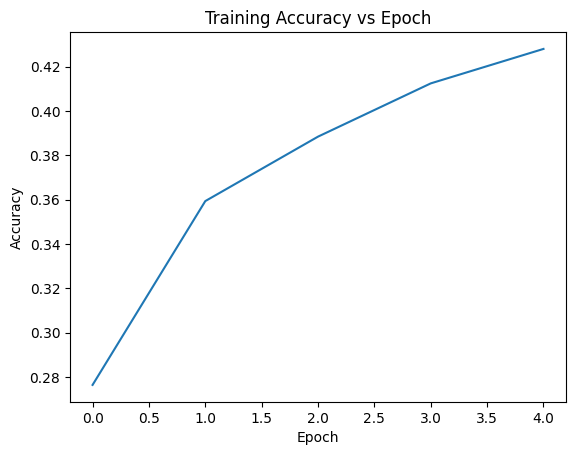

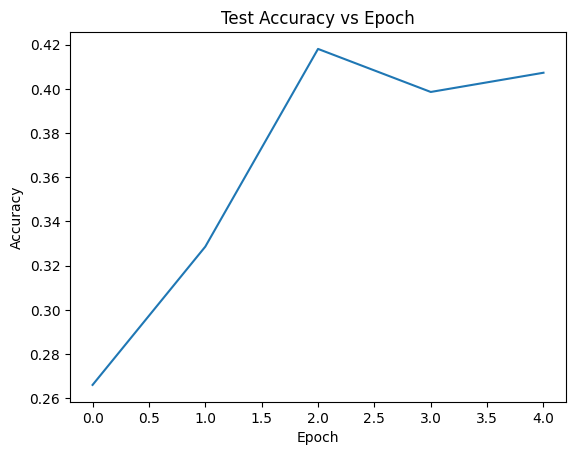

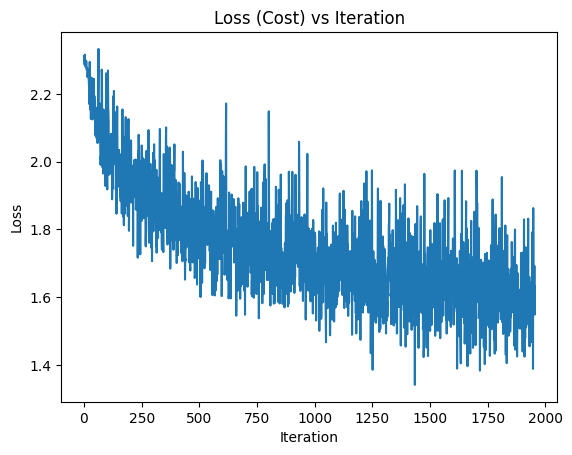

In [17]:
# 1) Training accuracy vs epoch
plt.figure()
plt.plot(train_acc_hist)
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 2) Test accuracy vs epoch
plt.figure()
plt.plot(test_acc_hist)
plt.title("Test Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 3) Loss vs iteration
plt.figure()
plt.plot(loss_hist)
plt.title("Loss (Cost) vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

PlOT THE 3 required graphs

We did NOT use torch.nn.Linear, torch.nn.ReLU, torch.optim, CrossEntropyLoss

We only used:

DataLoader and CIFAR dataset (allowed)

Basic tensor operations (these are fine)

**L2 Regularization in Training** - **WEEK2**

In [18]:
def train_fc_l2(model, train_loader, test_loader, epochs=5, lr=0.1, lambda_l2=0.001, device="cpu"):
    """
    Train a neural network with L2 regularization (weight decay).

    Total loss:
        L_total = L_data + λ * sum(W^2)

    Gradient update:
        dW = dW + 2 * λ * W

    Note:
        L2 regularization is applied ONLY to weights, not biases.
    """

    loss_history = []
    train_acc_hist = []
    test_acc_hist = []

    for epoch in range(1, epochs + 1):
        model_loss = 0.0
        model_acc = 0.0
        steps = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # ----------------------------------------
            # Step 1: Forward pass
            # ----------------------------------------
            logits = model.forward(xb)

            # ----------------------------------------
            # Step 2: Cross-entropy loss
            # ----------------------------------------
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # ----------------------------------------
            # Step 3: Backward pass
            # ----------------------------------------
            model.backward(dlogits)

            # ----------------------------------------
            # Step 4: Compute L2 penalty (weights only)
            # ----------------------------------------
            l2_penalty = 0.0
            for i, param in enumerate(model.params()):
                w = param[0]

                # Apply only to weights (skip biases)
                if i % 2 == 0:
                    l2_penalty += torch.sum(w ** 2)

            total_loss = loss + lambda_l2 * l2_penalty

            # ----------------------------------------
            # Step 5: Add L2 gradient
            # ----------------------------------------
            for i, param in enumerate(model.params()):
                w = param[0]
                dw = param[1]

                if i % 2 == 0:
                    dw += 2 * lambda_l2 * w

            # ----------------------------------------
            # Step 6: Update parameters (SGD)
            # ----------------------------------------
            sgd_step(model.params(), lr=lr)

            # ----------------------------------------
            # Logging
            # ----------------------------------------
            loss_history.append(total_loss.item())
            model_loss += total_loss.item()
            model_acc += accuracy_from_logits(logits, yb)
            steps += 1

        train_acc = model_acc / steps
        train_acc_hist.append(train_acc)

        test_acc = evaluate(model, test_loader, device=device)
        test_acc_hist.append(test_acc)

        print(f"Epoch {epoch}: train_loss={model_loss/steps:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

    return loss_history, train_acc_hist, test_acc_hist


L2 Regularization Experiment

We create a NEW model instance so it starts with fresh weights.
This ensures the L2 experiment is independent from the baseline model.

Train the model using L2 regularization.
lambda_l2 controls how strong the penalty is on large weights.
A small value (0.001) is commonly used to prevent overfitting.

In [19]:
# --------------------------------------------------
# Initialize a new instance of the Fully Connected Network
#
# This model will be trained with L2 regularization
# (penalizing large weights to reduce overfitting)
# --------------------------------------------------
model_l2 = FCNet(device=device)


# --------------------------------------------------
# Train the model using L2 regularization
#
# Inputs:
#   model_l2      : custom neural network
#   train_loader  : training dataset
#   test_loader   : test dataset for evaluation
#   epochs        : number of training iterations over dataset
#   lr            : learning rate (step size for updates)
#   lambda_l2     : L2 regularization strength
#   device        : CPU or GPU
#
# Inside train_fc_l2():
#
#   1. Forward pass:
#        logits = model.forward(x)
#
#   2. Compute loss:
#        Cross-entropy loss:
#            L_data = -1/N * sum log(p(correct class))
#
#   3. Add L2 regularization:
#        L_total = L_data + λ * sum(W^2)
#
#   4. Backward pass:
#        Compute gradients using backpropagation
#
#   5. Add L2 gradient:
#        dW = dW + 2 * λ * W
#
#   6. Update parameters (SGD):
#        W = W - lr * dW
#
# Outputs:
#   loss_hist_l2      : loss values during training
#   train_acc_hist_l2 : training accuracy per epoch
#   test_acc_hist_l2  : test accuracy per epoch
# --------------------------------------------------
loss_hist_l2, train_acc_hist_l2, test_acc_hist_l2 = train_fc_l2(
    model_l2, train_loader, test_loader,
    epochs=5, lr=0.1, lambda_l2=0.001, device=device
)

Epoch 1: train_loss=2.0634 train_acc=0.2780 test_acc=0.3371
Epoch 2: train_loss=1.8787 train_acc=0.3547 test_acc=0.3974
Epoch 3: train_loss=1.8128 train_acc=0.3827 test_acc=0.3034
Epoch 4: train_loss=1.7723 train_acc=0.4019 test_acc=0.4179
Epoch 5: train_loss=1.7304 train_acc=0.4192 test_acc=0.4088


Training accuracy plot

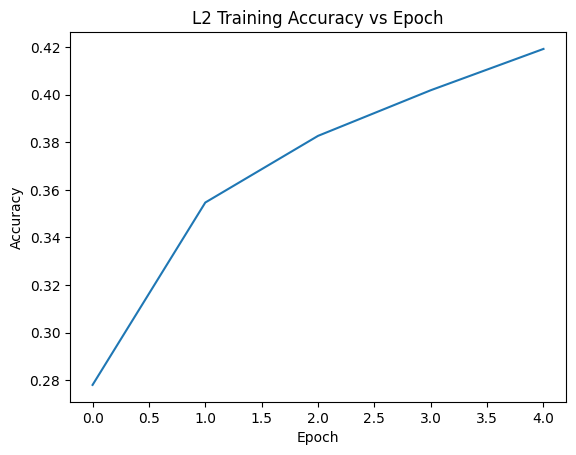

In [20]:
# -------------------------------------------------------------
# Plot Training Accuracy for L2 Model
# Shows how the model performance improves across epochs
# -------------------------------------------------------------

plt.figure()
plt.plot(train_acc_hist_l2)
plt.title("L2 Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Test accuracy plot

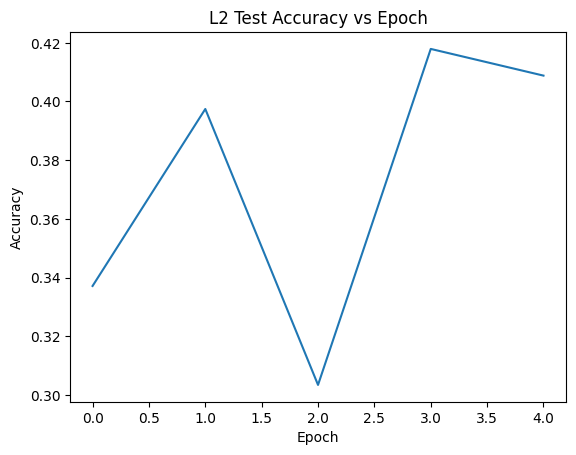

In [21]:
# -------------------------------------------------------------
# Plot Test Accuracy for L2 Model
# This helps evaluate how well the model generalizes to unseen data
# -------------------------------------------------------------

plt.figure()
plt.plot(test_acc_hist_l2)
plt.title("L2 Test Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Loss plot

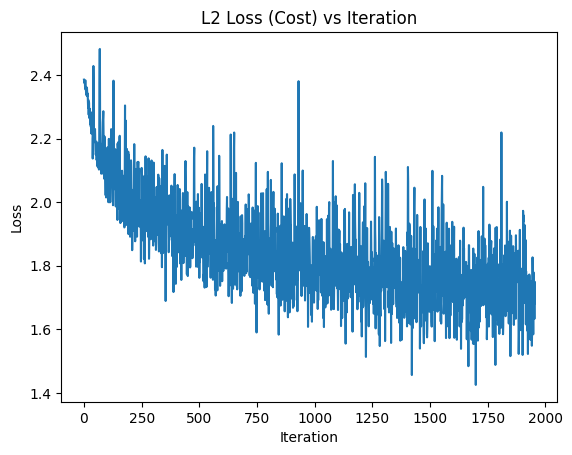

In [22]:
# -------------------------------------------------------------
# Plot Loss vs Iteration for L2 Model
# Loss should generally decrease as training progresses
# -------------------------------------------------------------

plt.figure()
plt.plot(loss_hist_l2)
plt.title("L2 Loss (Cost) vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

**Dropout Function**

In [23]:
def manual_dropout(x, p=0.5, training=True):
    """
    Manual Dropout Implementation

    Dropout randomly sets a fraction of activations to zero during training
    to prevent overfitting.

    Inputs:
        x        : input tensor (any shape)
        p        : probability of dropping a neuron
        training : whether model is in training mode

    --------------------------------------------------
    During training:

        1. Create a random mask:
            mask ~ Bernoulli(1 - p)

        2. Apply mask:
            out = x * mask

        3. Scale output:
            out = out / (1 - p)

        This is called "inverted dropout", which keeps:
            E[out] = x

    --------------------------------------------------
    During testing:

        No dropout is applied:
            out = x

    --------------------------------------------------
    Returns:
        out  : output tensor
        mask : dropout mask (used for backward pass)
    """

    # If not training, return input directly (no dropout)
    if not training:
        return x, None

    # Generate mask: keep neurons with probability (1 - p)
    mask = (torch.rand_like(x) > p).float()

    # Apply dropout and scale
    out = x * mask / (1 - p)

    return out, mask

Dropout model class

In [24]:
# -------------------------------------------------------------
# Fully Connected Network with Manual Dropout
#
# Architecture:
#   Input -> Linear -> ReLU -> Dropout -> Linear -> Output logits
#
# CIFAR-10 image size:
#   32 x 32 x 3 = 3072 input features after flattening
# -------------------------------------------------------------

class FCNetDropout:
    def __init__(self, input_dim=32*32*3, hidden_dim=128, output_dim=10, dropout_p=0.5, device="cpu"):
        """
        Initialize model parameters.

        input_dim  : number of input features (3072 for CIFAR-10)
        hidden_dim : number of neurons in hidden layer
        output_dim : number of classes (10 for CIFAR-10)
        dropout_p  : probability of dropping a hidden neuron
        device     : cpu or gpu
        """
        self.device = device
        self.dropout_p = dropout_p

        # --------------------------------------------------
        # Weights and biases
        #
        # First layer:
        #   z1 = xW1 + b1
        #
        # Second layer:
        #   logits = a1W2 + b2
        # --------------------------------------------------
        self.W1 = 0.01 * torch.randn(input_dim, hidden_dim, device=device)
        self.b1 = torch.zeros(hidden_dim, device=device)

        self.W2 = 0.01 * torch.randn(hidden_dim, output_dim, device=device)
        self.b2 = torch.zeros(output_dim, device=device)

        # Gradients
        self.dW1 = torch.zeros_like(self.W1)
        self.db1 = torch.zeros_like(self.b1)
        self.dW2 = torch.zeros_like(self.W2)
        self.db2 = torch.zeros_like(self.b2)

        # Cache values for backward pass
        self.x = None
        self.z1 = None
        self.a1 = None
        self.dropout_mask = None
        self.logits = None

    def forward(self, xb, training=True):
        """
        Forward pass

        Step 1: Flatten input image
            x shape: (N, 3072)

        Step 2: First linear layer
            z1 = xW1 + b1

        Step 3: Manual ReLU activation
            a1 = max(0, z1)

        Step 4: Manual dropout during training
            a1_dropout = a1 * mask / (1 - p)

        Step 5: Output layer
            logits = a1W2 + b2
        """
        # Flatten input from (N, 3, 32, 32) to (N, 3072)
        x = xb.view(xb.shape[0], -1)

        # First linear layer
        z1 = x @ self.W1 + self.b1

        # Manual ReLU
        a1 = z1 * (z1 > 0)

        # Apply dropout only during training
        if training:
            a1, self.dropout_mask = manual_dropout(a1, p=self.dropout_p)
        else:
            self.dropout_mask = None

        # Output layer
        logits = a1 @ self.W2 + self.b2

        # Save values for backward pass
        self.x = x
        self.z1 = z1
        self.a1 = a1
        self.logits = logits

        return logits

    def backward(self, dlogits):
        """
        Backward pass

        Given:
            dlogits = dL/d(logits)

        Output layer gradients:
            dW2 = a1^T · dlogits
            db2 = sum(dlogits)

        Backpropagate to hidden layer:
            da1 = dlogits · W2^T

        Dropout backward:
            da1 = da1 * mask / (1 - p)

        ReLU backward:
            dz1 = da1 * 1(z1 > 0)

        Hidden layer gradients:
            dW1 = x^T · dz1
            db1 = sum(dz1)
        """

        # --------------------------------------------------
        # Gradients for second linear layer
        # --------------------------------------------------
        self.dW2 = self.a1.t() @ dlogits
        self.db2 = dlogits.sum(dim=0)

        # Backpropagate into hidden activations
        da1 = dlogits @ self.W2.t()

        # --------------------------------------------------
        # Backward pass through dropout
        # Only active neurons receive gradient
        # --------------------------------------------------
        if self.dropout_mask is not None:
            da1 = da1 * self.dropout_mask / (1 - self.dropout_p)

        # --------------------------------------------------
        # Backward pass through ReLU
        # ReLU derivative:
        #   1 if z1 > 0
        #   0 otherwise
        # --------------------------------------------------
        dz1 = da1 * (self.z1 > 0).float()

        # Gradients for first linear layer
        self.dW1 = self.x.t() @ dz1
        self.db1 = dz1.sum(dim=0)

    def params(self):
        """
        Return model parameters and corresponding gradients.
        Used for manual SGD updates.
        """
        return [
            (self.W1, self.dW1),
            (self.b1, self.db1),
            (self.W2, self.dW2),
            (self.b2, self.db2),
        ]

Separate training function for dropout

In [25]:
# --------------------------------------------------
# Evaluate model accuracy (Dropout OFF)
#
# During evaluation:
#   - No gradients are computed
#   - Dropout is disabled
#
# Accuracy formula:
#   accuracy = (# correct predictions) / (total samples)
# --------------------------------------------------

@torch.no_grad()
def evaluate_dropout(model, loader, device="cpu"):
    """
    Evaluate model performance on validation/test data.

    Inputs:
        model  : trained FCNetDropout model
        loader : data loader (validation or test set)
        device : cpu or gpu

    Returns:
        Average accuracy across all batches
    """

    acc_sum = 0.0
    steps = 0

    # Loop through dataset
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        # Forward pass with dropout disabled
        logits = model.forward(xb, training=False)

        # Compute accuracy for this batch
        acc_sum += accuracy_from_logits(logits, yb)
        steps += 1

    # Return average accuracy
    return acc_sum / steps

In [26]:
# --------------------------------------------------
# Train Fully Connected Network with Manual Dropout
#
# During training:
#   - Dropout is turned ON
#   - Some hidden activations are randomly dropped
#   - This helps reduce overfitting
# --------------------------------------------------

def train_fc_dropout(model, train_loader, test_loader, epochs=5, lr=0.1, device="cpu"):
    """
    Train a fully connected neural network with manual dropout.

    Inputs:
        model       : custom FCNetDropout model
        train_loader: training data loader
        test_loader : test data loader
        epochs      : number of training epochs
        lr          : learning rate
        device      : cpu or gpu

    Returns:
        loss_history   : loss value for each training step
        train_acc_hist : average training accuracy per epoch
        test_acc_hist  : average test accuracy per epoch
    """

    # Store training history
    loss_history = []
    train_acc_hist = []
    test_acc_hist = []

    # Repeat training for the given number of epochs
    for epoch in range(1, epochs + 1):
        model_loss = 0.0
        model_acc = 0.0
        steps = 0

        # Loop through each batch in the training set
        for xb, yb in train_loader:
            # Move batch to selected device
            xb = xb.to(device)
            yb = yb.to(device)

            # --------------------------------------------------
            # Step 1: Forward pass with dropout enabled
            #
            # Network computes:
            #   z1 = xW1 + b1
            #   a1 = ReLU(z1)
            #   a1_dropout = a1 * mask / (1 - p)
            #   logits = a1_dropout W2 + b2
            # --------------------------------------------------
            logits = model.forward(xb, training=True)

            # --------------------------------------------------
            # Step 2: Compute loss and gradient
            #
            # Cross-entropy loss:
            #   L = -1/N * sum log(p(correct class))
            #
            # dlogits = gradient of loss w.r.t logits
            # --------------------------------------------------
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # --------------------------------------------------
            # Step 3: Backward pass
            #
            # Compute gradients for:
            #   W2, b2, W1, b1
            # including dropout and ReLU effects
            # --------------------------------------------------
            model.backward(dlogits)

            # --------------------------------------------------
            # Step 4: Update parameters using manual SGD
            #
            # Update rule:
            #   parameter = parameter - lr * gradient
            # --------------------------------------------------
            sgd_step(model.params(), lr=lr)

            # Record batch loss
            loss_history.append(loss.item())

            # Add batch loss and accuracy to epoch totals
            model_loss += loss.item()
            model_acc += accuracy_from_logits(logits, yb)
            steps += 1

        # Average training accuracy for this epoch
        train_acc = model_acc / steps
        train_acc_hist.append(train_acc)

        # Evaluate model on test data with dropout turned OFF
        test_acc = evaluate_dropout(model, test_loader, device=device)
        test_acc_hist.append(test_acc)

        # Print training progress for this epoch
        print(f"Epoch {epoch}: train_loss={model_loss/steps:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

    return loss_history, train_acc_hist, test_acc_hist

Dropout experiment

In [27]:
# --------------------------------------------------
# Dropout Experiment
#
# Create a new instance of the custom FC network
# with manual dropout.
#
# dropout_p = 0.2 means:
#   - 20% of hidden neurons are randomly dropped
#   - 80% of hidden neurons are kept
#
# Dropout is applied only during training
# to reduce overfitting.
#
# A new model is created so this experiment is
# independent from previous runs.
# --------------------------------------------------
model_dropout = FCNetDropout(device=device, dropout_p=0.2)


# --------------------------------------------------
# Train the dropout model
#
# Inputs:
#   model_dropout : custom FC network with manual dropout
#   train_loader  : training dataset
#   test_loader   : test dataset
#   epochs        : number of passes through training data
#   lr            : learning rate for SGD updates
#   device        : cpu or gpu
#
# During training:
#   1. Forward pass with dropout ON
#   2. Compute cross-entropy loss
#   3. Backward pass through output layer, dropout,
#      ReLU, and hidden layer
#   4. Update parameters using manual SGD
#
# During evaluation:
#   - Dropout is turned OFF
#
# Outputs:
#   loss_hist_dropout      : training loss over time
#   train_acc_hist_dropout : training accuracy per epoch
#   test_acc_hist_dropout  : test accuracy per epoch
# --------------------------------------------------
loss_hist_dropout, train_acc_hist_dropout, test_acc_hist_dropout = train_fc_dropout(
    model_dropout,
    train_loader,
    test_loader,
    epochs=5,
    lr=0.1,
    device=device
)

Epoch 1: train_loss=2.0123 train_acc=0.2604 test_acc=0.3188
Epoch 2: train_loss=1.8338 train_acc=0.3402 test_acc=0.3709
Epoch 3: train_loss=1.7626 train_acc=0.3711 test_acc=0.4065
Epoch 4: train_loss=1.7124 train_acc=0.3893 test_acc=0.3761
Epoch 5: train_loss=1.6766 train_acc=0.4049 test_acc=0.3965


Train

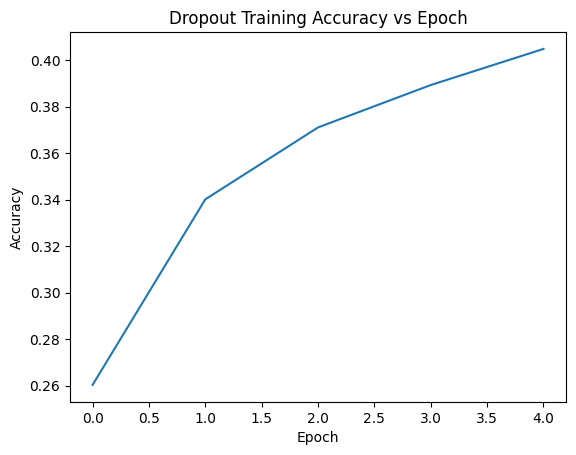

In [28]:
plt.figure()
plt.plot(train_acc_hist_dropout)
plt.title("Dropout Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Test

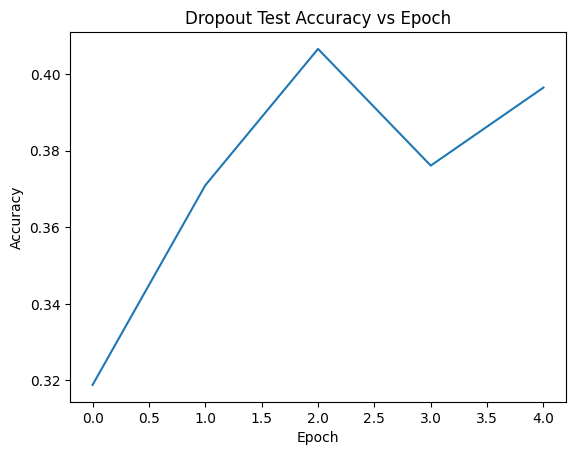

In [29]:
plt.figure()
plt.plot(test_acc_hist_dropout)
plt.title("Dropout Test Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Loss

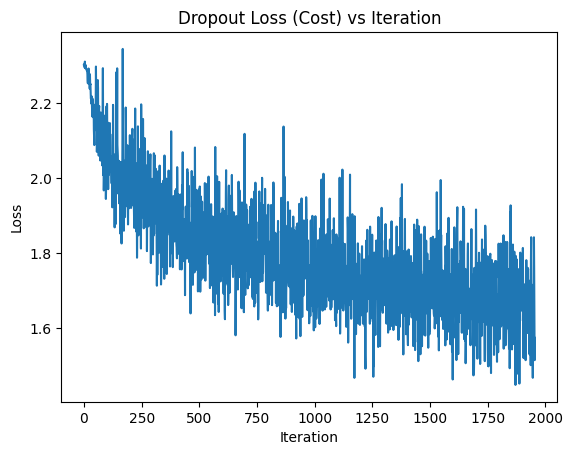

In [30]:
plt.figure()
plt.plot(loss_hist_dropout)
plt.title("Dropout Loss (Cost) vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

Final Comparison

In [31]:
print("===== Final Accuracy Comparison =====")
print(f"Baseline  - Train Acc: {train_acc_hist[-1]:.4f}, Test Acc: {test_acc_hist[-1]:.4f}")
print(f"L2        - Train Acc: {train_acc_hist_l2[-1]:.4f}, Test Acc: {test_acc_hist_l2[-1]:.4f}")
print(f"Dropout   - Train Acc: {train_acc_hist_dropout[-1]:.4f}, Test Acc: {test_acc_hist_dropout[-1]:.4f}")

===== Final Accuracy Comparison =====
Baseline  - Train Acc: 0.4280, Test Acc: 0.4073
L2        - Train Acc: 0.4192, Test Acc: 0.4088
Dropout   - Train Acc: 0.4049, Test Acc: 0.3965


**Week3**

**CNN - CIFAR-10 transforms and loaders**

In [32]:
# --------------------------------------------------
# Dataset and DataLoaders for CNN Experiments
# --------------------------------------------------
cnn_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

cnn_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

cnn_train_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=cnn_train_transform
)

cnn_test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=cnn_test_transform
)

cnn_train_loader = DataLoader(
    cnn_train_set,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

cnn_test_loader = DataLoader(
    cnn_test_set,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("CNN train size:", len(cnn_train_set))
print("CNN test size:", len(cnn_test_set))

CNN train size: 50000
CNN test size: 10000


Manual Momentum optimizer

In [33]:
# --------------------------------------------------
# Manual SGD with Momentum Optimizer
#
# This optimizer updates parameters using:
#
#   v = momentum * v - lr * gradient
#   parameter = parameter + v
#
# Momentum helps accelerate learning and smooth updates
# by accumulating past gradients.
# --------------------------------------------------

class SGDMomentum:
    def __init__(self, params, lr=0.01, momentum=0.9):
        """
        Initialize optimizer.

        params   : list of (parameter, gradient) tuples
        lr       : learning rate (η)
        momentum : momentum factor (μ)
        """

        self.params = params
        self.lr = lr
        self.momentum = momentum

        # Initialize velocity for each parameter
        self.velocities = []
        for p, dp in self.params:
            self.velocities.append(torch.zeros_like(p))

    def step(self):
        """
        Perform one optimization step.

        Update rules:

            v_t = μ * v_{t-1} - lr * grad
            param = param + v_t
        """

        for i, (p, dp) in enumerate(self.params):

            # Update velocity
            self.velocities[i] = self.momentum * self.velocities[i] - self.lr * dp

            # Update parameter
            p += self.velocities[i]

        # --------------------------------------------------
        # Reset gradients after update
        # --------------------------------------------------
        for p, dp in self.params:
            dp.zero_()

faster SGD momentum


In [34]:
class SGDMomentum:
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = params
        self.lr = lr
        self.momentum = momentum

        # Initialize velocities
        self.velocities = [torch.zeros_like(p) for p, _ in self.params]

    def step(self):
        for i, (p, dp) in enumerate(self.params):

            # v = μ * v - lr * grad
            self.velocities[i] = self.momentum * self.velocities[i] - self.lr * dp

            # param = param + v
            p += self.velocities[i]

            # Reset gradient immediately
            dp.zero_()

Manual Adam optimizer

In [35]:
# --------------------------------------------------
# Manual Adam Optimizer
#
# Adam combines:
#   - Momentum (first moment)
#   - RMSProp (second moment)
#
# Update rule:
#   m = β1 * m + (1 - β1) * grad
#   v = β2 * v + (1 - β2) * grad^2
#
#   m_hat = m / (1 - β1^t)
#   v_hat = v / (1 - β2^t)
#
#   param = param - lr * m_hat / (sqrt(v_hat) + eps)
# --------------------------------------------------

class AdamManual:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        """
        Initialize Adam optimizer.

        params : list of (parameter, gradient) tuples
        lr     : learning rate (η)
        beta1  : decay rate for first moment (momentum)
        beta2  : decay rate for second moment (variance)
        eps    : small value to avoid division by zero
        """

        self.params = params
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        # time step
        self.t = 0

        # first moment (mean of gradients)
        self.m = []

        # second moment (variance of gradients)
        self.v = []

        # initialize m and v for each parameter
        for p, dp in self.params:
            self.m.append(torch.zeros_like(p))
            self.v.append(torch.zeros_like(p))

    def step(self):
        """
        Perform one optimization step using Adam.
        """

        # increment time step
        self.t += 1

        for i, (p, dp) in enumerate(self.params):

            # -------------------------------
            # Update biased first moment
            # -------------------------------
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * dp

            # -------------------------------
            # Update biased second moment
            # -------------------------------
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (dp ** 2)

            # -------------------------------
            # Bias correction
            # -------------------------------
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            # -------------------------------
            # Parameter update
            # -------------------------------
            p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

        # -------------------------------
        # Reset gradients after update
        # -------------------------------
        for p, dp in self.params:
            dp.zero_()

Learning rate decay functions

In [36]:
import math

# --------------------------------------------------
# Cosine Annealing Learning Rate Scheduler
#
# Gradually decreases learning rate using a cosine curve.
#
# Formula:
#   lr = initial_lr * 0.5 * (1 + cos(pi * epoch / total_epochs))
#
# Behavior:
#   - Starts high
#   - Smoothly decays toward 0
#   - No sudden jumps
# --------------------------------------------------
def cosine_lr(initial_lr, epoch, total_epochs):
    return initial_lr * 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))


# --------------------------------------------------
# Step Decay Learning Rate Scheduler
#
# Reduces learning rate at fixed intervals.
#
# Formula:
#   lr = initial_lr * (drop ^ floor(epoch / every))
#
# Parameters:
#   drop  : factor to reduce LR (e.g., 0.5 halves it)
#   every : number of epochs before reducing LR
#
# Example:
#   every = 10:
#     epoch 0–9   → lr
#     epoch 10–19 → lr * drop
#     epoch 20–29 → lr * drop^2
# --------------------------------------------------
def step_decay_lr(initial_lr, epoch, drop=0.5, every=10):
    return initial_lr * (drop ** (epoch // every))

Adding additonal comments so we have covered

Momentum

Adam

Cosine LR decay

Step LR decay

**CNN Model**

In [37]:
import torch
import torch.nn.functional as F
import math


# ==================================================
# Manual zero padding
# ==================================================
def manual_pad(x, pad):
    if pad == 0:
        return x

    N, C, H, W = x.shape
    out = torch.zeros(
        (N, C, H + 2 * pad, W + 2 * pad),
        device=x.device,
        dtype=x.dtype
    )
    out[:, :, pad:pad + H, pad:pad + W] = x
    return out


# ==================================================
# Manual ReLU
# ==================================================
class ReLU:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x > 0)
        return x * self.mask

    def backward(self, dout):
        return dout * self.mask


# ==================================================
# Manual Linear Layer
# ==================================================
class Linear:
    def __init__(self, in_features, out_features, device="cpu"):
        scale = math.sqrt(2.0 / in_features)
        self.W = scale * torch.randn(in_features, out_features, device=device)
        self.b = torch.zeros(out_features, device=device)

        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        self.x = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW.copy_(self.x.t() @ dout)
        self.db.copy_(dout.sum(dim=0))
        dx = dout @ self.W.t()
        return dx


# ==================================================
# Manual Conv2D Layer
# ==================================================
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, device="cpu"):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.device = device

        fan_in = in_channels * kernel_size * kernel_size
        scale = math.sqrt(2.0 / fan_in)

        self.W = scale * torch.randn(
            out_channels, in_channels, kernel_size, kernel_size, device=device
        )
        self.b = torch.zeros(out_channels, device=device)

        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        self.x = None
        self.x_padded = None
        self.x_cols = None

    def forward(self, x):
        self.x = x

        P = self.padding
        S = self.stride
        KH = self.kernel_size
        KW = self.kernel_size

        self.x_padded = manual_pad(x, P)
        self.x_cols = self.x_padded.unfold(2, KH, S).unfold(3, KW, S)

        out = torch.einsum('nchwkl,fckl->nfhw', self.x_cols, self.W)
        out = out + self.b[None, :, None, None]
        return out

    def backward(self, dout):
        _, _, KH, KW = self.W.shape
        P = self.padding
        S = self.stride
        H_out = dout.shape[2]
        W_out = dout.shape[3]

        self.db.copy_(dout.sum(dim=(0, 2, 3)))
        self.dW.copy_(torch.einsum('nchwkl,nfhw->fckl', self.x_cols, dout))

        dx_cols = torch.einsum('nfhw,fckl->nchwkl', dout, self.W)
        dx_padded = torch.zeros_like(self.x_padded)

        for kh in range(KH):
            for kw in range(KW):
                dx_padded[:, :, kh:kh + S * H_out:S, kw:kw + S * W_out:S] += dx_cols[:, :, :, :, kh, kw]

        if P > 0:
            dx = dx_padded[:, :, P:-P, P:-P]
        else:
            dx = dx_padded

        return dx


# ==================================================
# AvgPool2D
# Note: F.avg_pool2d is allowed by your project rules
# ==================================================
class AvgPool2D:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride
        self.x_shape = None

    def forward(self, x):
        self.x_shape = x.shape
        return F.avg_pool2d(x, kernel_size=self.kernel_size, stride=self.stride)

    def backward(self, dout):
        K = self.kernel_size
        S = self.stride

        if K == S:
            dx = dout.repeat_interleave(K, dim=2).repeat_interleave(K, dim=3) / (K * K)
            return dx

        N, C, H, W = self.x_shape
        dx = torch.zeros(self.x_shape, device=dout.device)

        H_out = dout.shape[2]
        W_out = dout.shape[3]

        for i in range(H_out):
            for j in range(W_out):
                h_start = i * S
                h_end = h_start + K
                w_start = j * S
                w_end = w_start + K
                dx[:, :, h_start:h_end, w_start:w_end] += dout[:, :, i:i+1, j:j+1] / (K * K)

        return dx


# ==================================================
# Softmax + Cross Entropy
# ==================================================
def softmax(logits):
    z = logits - logits.max(dim=1, keepdim=True).values
    exp = torch.exp(z)
    return exp / exp.sum(dim=1, keepdim=True)


def cross_entropy_loss_from_logits(logits, y):
    N = logits.shape[0]
    probs = softmax(logits)

    eps = 1e-12
    correct_probs = probs[torch.arange(N, device=logits.device), y]
    loss = (-torch.log(correct_probs + eps)).mean()

    dlogits = probs.clone()
    dlogits[torch.arange(N, device=logits.device), y] -= 1.0
    dlogits /= N

    return loss, dlogits


# ==================================================
# Accuracy
# ==================================================
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


# ==================================================
# Manual CNN
# ==================================================
class ManualCNN:
    def __init__(self, num_classes=10, device="cpu"):
        self.device = device

        # self.conv1 = Conv2D(3, 16, kernel_size=3, stride=1, padding=1, device=device)
        # self.relu1 = ReLU()
        # self.pool1 = AvgPool2D(kernel_size=2, stride=2)

        # self.conv2 = Conv2D(16, 32, kernel_size=3, stride=1, padding=1, device=device)
        # self.relu2 = ReLU()
        # self.pool2 = AvgPool2D(kernel_size=2, stride=2)

        # self.fc1 = Linear(32 * 8 * 8, 128, device=device)
        # self.relu3 = ReLU()
        # self.fc2 = Linear(128, num_classes, device=device)

        self.conv1 = Conv2D(3, 32, kernel_size=3, stride=1, padding=1, device=device)
        self.relu1 = ReLU()
        self.pool1 = AvgPool2D(kernel_size=2, stride=2)

        self.conv2 = Conv2D(32, 64, kernel_size=3, stride=1, padding=1, device=device)
        self.relu2 = ReLU()
        self.pool2 = AvgPool2D(kernel_size=2, stride=2)

        self.fc1 = Linear(64 * 8 * 8, 256, device=device)
        self.relu3 = ReLU()
        self.fc2 = Linear(256, num_classes, device=device)

        self.last_conv_shape = None

    def forward(self, x):
        x = self.conv1.forward(x)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        x = self.conv2.forward(x)
        x = self.relu2.forward(x)
        x = self.pool2.forward(x)

        self.last_conv_shape = x.shape
        x = x.reshape(x.shape[0], -1)

        x = self.fc1.forward(x)
        x = self.relu3.forward(x)
        logits = self.fc2.forward(x)

        return logits

    def backward(self, dlogits):
        dx = self.fc2.backward(dlogits)
        dx = self.relu3.backward(dx)
        dx = self.fc1.backward(dx)

        dx = dx.reshape(self.last_conv_shape)

        dx = self.pool2.backward(dx)
        dx = self.relu2.backward(dx)
        dx = self.conv2.backward(dx)

        dx = self.pool1.backward(dx)
        dx = self.relu1.backward(dx)
        dx = self.conv1.backward(dx)

        return dx

    def zero_grad(self):
        self.conv1.dW.zero_()
        self.conv1.db.zero_()
        self.conv2.dW.zero_()
        self.conv2.db.zero_()
        self.fc1.dW.zero_()
        self.fc1.db.zero_()
        self.fc2.dW.zero_()
        self.fc2.db.zero_()

    def params(self):
        return [
            (self.conv1.W, self.conv1.dW),
            (self.conv1.b, self.conv1.db),
            (self.conv2.W, self.conv2.dW),
            (self.conv2.b, self.conv2.db),
            (self.fc1.W, self.fc1.dW),
            (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),
            (self.fc2.b, self.fc2.db),
        ]

CNN accuracy function

In [38]:
# --------------------------------------------------
# Evaluate Manual CNN
#
# No gradients needed during evaluation
# Returns accuracy as a fraction (example: 0.1032)
# --------------------------------------------------

@torch.no_grad()
def evaluate_cnn(model, loader, device="cpu"):
    correct = 0
    total = 0

    # Turn off dropout during evaluation if it exists
    if hasattr(model, "dropout"):
        model.dropout.training = False

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model.forward(xb)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == yb).sum().item()
        total += yb.size(0)

    # Accuracy as fraction, not percent
    acc = correct / total

    # Turn dropout back on for training
    if hasattr(model, "dropout"):
        model.dropout.training = True

    return acc

CNN training loop with manual optimizer and LR decay

faster training

In [39]:

def train_cnn_manual(model, train_loader, test_loader,
                     optimizer_type="momentum",
                     scheduler_type=None,
                     epochs=20,
                     initial_lr=0.001,
                     device="cpu"):

    # Store history for plotting later
    train_loss_hist = []
    train_acc_hist = []
    test_acc_hist = []
    lr_hist = []

    # --------------------------------------------------
    # Initialize optimizer (manual implementation)
    # --------------------------------------------------
    if optimizer_type == "momentum":
        optimizer = SGDMomentum(model.params(), lr=initial_lr, momentum=0.9)
    elif optimizer_type == "adam":
        optimizer = AdamManual(model.params(), lr=initial_lr)
    else:
        raise ValueError("optimizer_type must be 'momentum' or 'adam'")

    # --------------------------------------------------
    # Training loop over epochs
    # --------------------------------------------------
    for epoch in range(1, epochs + 1):

        running_loss = 0.0   # sum of batch losses
        correct = 0          # number of correct predictions
        total = 0            # total samples

        # --------------------------------------------------
        # Learning rate scheduler (manual)
        # --------------------------------------------------
        if scheduler_type == "cosine":
            current_lr = cosine_lr(initial_lr, epoch - 1, epochs)
        elif scheduler_type == "step":
            current_lr = step_decay_lr(initial_lr, epoch - 1, drop=0.5, every=10)
        else:
            current_lr = initial_lr  # constant LR

        optimizer.lr = current_lr
        lr_hist.append(current_lr)

        # --------------------------------------------------
        # If model has dropout, enable training mode
        # --------------------------------------------------
        if hasattr(model, "dropout"):
            model.dropout.training = True

        # --------------------------------------------------
        # Loop over mini-batches
        # --------------------------------------------------
        for xb, yb in train_loader:

            # Move data to CPU/GPU
            xb = xb.to(device)
            yb = yb.to(device)

            # -----------------------
            # Forward pass
            # -----------------------
            logits = model.forward(xb)

            # -----------------------
            # Compute loss + gradient
            # -----------------------
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # -----------------------
            # Backward pass
            # -----------------------
            model.backward(dlogits)

            # -----------------------
            # Update parameters
            # -----------------------
            optimizer.step()

            # -----------------------
            # Logging metrics
            # -----------------------
            running_loss += loss.item()

            preds = torch.argmax(logits, dim=1)   # predicted class
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        # --------------------------------------------------
        # Compute epoch-level metrics
        # --------------------------------------------------
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Evaluate on test dataset
        test_acc = evaluate_cnn(model, test_loader, device=device)

        # Save history
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        test_acc_hist.append(test_acc)

        # --------------------------------------------------
        # Print progress
        # --------------------------------------------------
        print(
            f"Epoch {epoch}: "
            f"lr={current_lr:.6f} "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc*100:.2f}% "
            f"test_acc={test_acc*100:.2f}%"
        )

    # Return all logs for analysis/plots
    return train_loss_hist, train_acc_hist, test_acc_hist, lr_hist

**Experiment 1: Momentum only**

In [40]:
# --------------------------------------------------
# Train Manual CNN using SGD with Momentum
#
# Create an instance of the custom CNN model.
# This model uses:
#   - manual convolution layers
#   - manual ReLU
#   - allowed pooling
#   - manual fully connected layers
#
# No nn.Conv2d, nn.Linear, or nn.Sequential are used.
# --------------------------------------------------
cnn_momentum = ManualCNN(num_classes=10, device=device)


# --------------------------------------------------
# Train the manual CNN with Momentum optimizer
#
# optimizer_type="momentum"
#   -> uses the custom SGDMomentum optimizer
#
# scheduler_type=None
#   -> learning rate stays constant
#
# epochs=20
#   -> train for 20 full passes through the dataset
#
# initial_lr=0.01
#   -> starting learning rate
# --------------------------------------------------
loss_momentum, train_acc_momentum, test_acc_momentum, lr_momentum = train_cnn_manual(
    cnn_momentum,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="momentum",
    scheduler_type=None,
    epochs=20,
    initial_lr=0.01,
    device=device
)

Epoch 1: lr=0.010000 train_loss=1.7060 train_acc=38.20% test_acc=48.19%
Epoch 2: lr=0.010000 train_loss=1.4356 train_acc=48.07% test_acc=53.74%
Epoch 3: lr=0.010000 train_loss=1.3218 train_acc=52.55% test_acc=58.75%
Epoch 4: lr=0.010000 train_loss=1.2262 train_acc=56.12% test_acc=61.20%
Epoch 5: lr=0.010000 train_loss=1.1522 train_acc=58.90% test_acc=63.43%
Epoch 6: lr=0.010000 train_loss=1.0830 train_acc=61.40% test_acc=66.08%
Epoch 7: lr=0.010000 train_loss=1.0410 train_acc=62.99% test_acc=65.88%
Epoch 8: lr=0.010000 train_loss=0.9900 train_acc=65.03% test_acc=68.37%
Epoch 9: lr=0.010000 train_loss=0.9542 train_acc=66.24% test_acc=67.59%
Epoch 10: lr=0.010000 train_loss=0.9266 train_acc=67.25% test_acc=70.09%
Epoch 11: lr=0.010000 train_loss=0.8932 train_acc=68.53% test_acc=70.45%
Epoch 12: lr=0.010000 train_loss=0.8654 train_acc=69.55% test_acc=70.58%
Epoch 13: lr=0.010000 train_loss=0.8454 train_acc=70.23% test_acc=72.93%
Epoch 14: lr=0.010000 train_loss=0.8232 train_acc=70.90% tes

Experiment 2: Momentum + Cosine decay

In [41]:
cnn_momentum_cosine = ManualCNN(num_classes=10, device=device)

loss_momentum_cosine, train_acc_momentum_cosine, test_acc_momentum_cosine, lr_momentum_cosine = train_cnn_manual(
    cnn_momentum_cosine,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="momentum",
    scheduler_type="cosine",
    epochs=20,
    initial_lr=0.005,
    device=device
)

Epoch 1: lr=0.005000 train_loss=1.7801 train_acc=36.14% test_acc=46.53%
Epoch 2: lr=0.004969 train_loss=1.5129 train_acc=45.36% test_acc=49.69%
Epoch 3: lr=0.004878 train_loss=1.4080 train_acc=49.30% test_acc=53.73%
Epoch 4: lr=0.004728 train_loss=1.3428 train_acc=51.60% test_acc=57.44%
Epoch 5: lr=0.004523 train_loss=1.2868 train_acc=54.02% test_acc=58.56%
Epoch 6: lr=0.004268 train_loss=1.2342 train_acc=56.07% test_acc=59.94%
Epoch 7: lr=0.003969 train_loss=1.1922 train_acc=57.54% test_acc=60.61%
Epoch 8: lr=0.003635 train_loss=1.1542 train_acc=58.86% test_acc=62.48%
Epoch 9: lr=0.003273 train_loss=1.1157 train_acc=60.48% test_acc=63.49%
Epoch 10: lr=0.002891 train_loss=1.0830 train_acc=61.71% test_acc=65.11%
Epoch 11: lr=0.002500 train_loss=1.0537 train_acc=62.72% test_acc=64.70%
Epoch 12: lr=0.002109 train_loss=1.0305 train_acc=63.45% test_acc=66.67%
Epoch 13: lr=0.001727 train_loss=1.0032 train_acc=64.43% test_acc=67.11%
Epoch 14: lr=0.001365 train_loss=0.9850 train_acc=65.13% tes

Experiment 3: Adam only

In [42]:
cnn_adam = ManualCNN(num_classes=10, device=device)

loss_adam, train_acc_adam, test_acc_adam, lr_adam = train_cnn_manual(
    cnn_adam,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type=None,
    epochs=20,
    initial_lr=0.001,
    device=device
)

Epoch 1: lr=0.001000 train_loss=1.5999 train_acc=42.54% test_acc=54.11%
Epoch 2: lr=0.001000 train_loss=1.2751 train_acc=54.70% test_acc=61.50%
Epoch 3: lr=0.001000 train_loss=1.1516 train_acc=59.01% test_acc=64.61%
Epoch 4: lr=0.001000 train_loss=1.0669 train_acc=62.41% test_acc=65.31%
Epoch 5: lr=0.001000 train_loss=0.9985 train_acc=64.57% test_acc=69.09%
Epoch 6: lr=0.001000 train_loss=0.9525 train_acc=66.28% test_acc=69.45%
Epoch 7: lr=0.001000 train_loss=0.9088 train_acc=67.96% test_acc=70.45%
Epoch 8: lr=0.001000 train_loss=0.8748 train_acc=69.17% test_acc=71.55%
Epoch 9: lr=0.001000 train_loss=0.8437 train_acc=70.28% test_acc=71.96%
Epoch 10: lr=0.001000 train_loss=0.8115 train_acc=71.42% test_acc=72.30%
Epoch 11: lr=0.001000 train_loss=0.7933 train_acc=72.10% test_acc=73.16%
Epoch 12: lr=0.001000 train_loss=0.7743 train_acc=73.00% test_acc=73.68%
Epoch 13: lr=0.001000 train_loss=0.7523 train_acc=73.51% test_acc=73.95%
Epoch 14: lr=0.001000 train_loss=0.7367 train_acc=74.09% tes

Experiment 4: Adam + Step decay

In [43]:
cnn_adam_step = ManualCNN(num_classes=10, device=device)

loss_adam_step, train_acc_adam_step, test_acc_adam_step, lr_adam_step = train_cnn_manual(
    cnn_adam_step,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type="step",
    epochs=20,
    initial_lr=0.001,
    device=device
)

Epoch 1: lr=0.001000 train_loss=1.6011 train_acc=42.32% test_acc=54.75%
Epoch 2: lr=0.001000 train_loss=1.2563 train_acc=55.28% test_acc=60.91%
Epoch 3: lr=0.001000 train_loss=1.1273 train_acc=60.08% test_acc=63.51%
Epoch 4: lr=0.001000 train_loss=1.0439 train_acc=62.91% test_acc=67.41%
Epoch 5: lr=0.001000 train_loss=0.9830 train_acc=65.30% test_acc=68.21%
Epoch 6: lr=0.001000 train_loss=0.9323 train_acc=66.99% test_acc=68.99%
Epoch 7: lr=0.001000 train_loss=0.8880 train_acc=68.58% test_acc=71.13%
Epoch 8: lr=0.001000 train_loss=0.8609 train_acc=69.69% test_acc=72.57%
Epoch 9: lr=0.001000 train_loss=0.8291 train_acc=70.69% test_acc=72.33%
Epoch 10: lr=0.001000 train_loss=0.8024 train_acc=71.74% test_acc=73.50%
Epoch 11: lr=0.000500 train_loss=0.7423 train_acc=73.85% test_acc=74.59%
Epoch 12: lr=0.000500 train_loss=0.7268 train_acc=74.38% test_acc=74.95%
Epoch 13: lr=0.000500 train_loss=0.7145 train_acc=74.84% test_acc=75.78%
Epoch 14: lr=0.000500 train_loss=0.7056 train_acc=75.35% tes

Plot test accuracy comparison

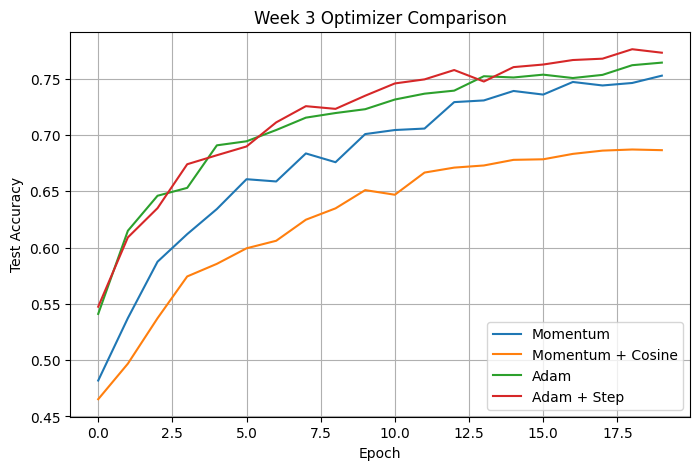

In [44]:
plt.figure(figsize=(8,5))
plt.plot(test_acc_momentum, label="Momentum")
plt.plot(test_acc_momentum_cosine, label="Momentum + Cosine")
plt.plot(test_acc_adam, label="Adam")
plt.plot(test_acc_adam_step, label="Adam + Step")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Week 3 Optimizer Comparison")
plt.legend()
plt.grid(True)
plt.show()

Plot training loss comparison

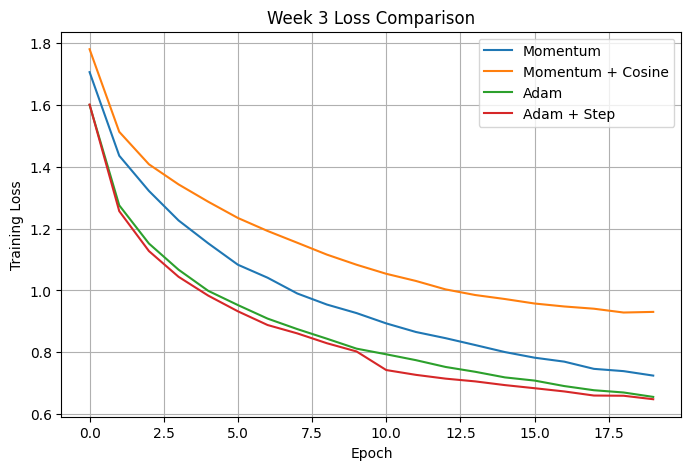

In [45]:
plt.figure(figsize=(8,5))
plt.plot(loss_momentum, label="Momentum")
plt.plot(loss_momentum_cosine, label="Momentum + Cosine")
plt.plot(loss_adam, label="Adam")
plt.plot(loss_adam_step, label="Adam + Step")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Week 3 Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

Print best results from ablation study

In [46]:
print("===== WEEK 3 OPTIMIZER COMPARISON =====")
print(f"Momentum best test acc:          {max(test_acc_momentum):.4f}")
print(f"Momentum + Cosine best test acc: {max(test_acc_momentum_cosine):.4f}")
print(f"Adam best test acc:              {max(test_acc_adam):.4f}")
print(f"Adam + Step best test acc:       {max(test_acc_adam_step):.4f}")

===== WEEK 3 OPTIMIZER COMPARISON =====
Momentum best test acc:          0.7528
Momentum + Cosine best test acc: 0.6872
Adam best test acc:              0.7644
Adam + Step best test acc:       0.7763


Final best model run for 75%+

In [49]:
best_cnn = ManualCNN(device=device)

best_loss, best_train_acc, best_test_acc, best_lr = train_cnn_manual(
    best_cnn,
    cnn_train_loader,
    cnn_test_loader,
    optimizer_type="adam",
    scheduler_type="step",
    epochs=30,
    initial_lr=0.001,
    device=device
)

Epoch 1: lr=0.001000 train_loss=1.6068 train_acc=42.03% test_acc=53.39%
Epoch 2: lr=0.001000 train_loss=1.2857 train_acc=53.92% test_acc=57.24%
Epoch 3: lr=0.001000 train_loss=1.1531 train_acc=58.78% test_acc=63.62%
Epoch 4: lr=0.001000 train_loss=1.0599 train_acc=62.36% test_acc=66.77%
Epoch 5: lr=0.001000 train_loss=0.9957 train_acc=64.58% test_acc=68.60%
Epoch 6: lr=0.001000 train_loss=0.9436 train_acc=66.63% test_acc=68.53%
Epoch 7: lr=0.001000 train_loss=0.9069 train_acc=67.98% test_acc=70.31%
Epoch 8: lr=0.001000 train_loss=0.8719 train_acc=69.08% test_acc=71.97%
Epoch 9: lr=0.001000 train_loss=0.8390 train_acc=70.36% test_acc=72.75%
Epoch 10: lr=0.001000 train_loss=0.8101 train_acc=71.37% test_acc=73.59%
Epoch 11: lr=0.000500 train_loss=0.7574 train_acc=73.25% test_acc=75.07%
Epoch 12: lr=0.000500 train_loss=0.7387 train_acc=74.01% test_acc=75.25%
Epoch 13: lr=0.000500 train_loss=0.7274 train_acc=74.51% test_acc=75.73%
Epoch 14: lr=0.000500 train_loss=0.7140 train_acc=74.85% tes

Final plot

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(best_train_acc, label="Train Accuracy")
plt.plot(best_test_acc, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Best CNN Run")
plt.legend()
plt.grid(True)
plt.show()

Final result print

In [ ]:
print("Final Best Test Accuracy:", max(best_test_acc))